# TLS focused distance analysis

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [2]:
from pathlib import Path
import sys
import os
import time
import warnings
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq


import scipy
from scipy.spatial import distance_matrix
from scipy.spatial.distance import cdist
from scipy import stats
import scipy.ndimage as ndi
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

from shapely.geometry import Point

from shapely.geometry import MultiPolygon
from alphashape import alphashape
from alphashape import optimizealpha
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

import pickle
import joblib

import random
import matplotlib.colors as mcolors

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter(action='ignore', category=Warning)

sys.version_info

sys.version_info(major=3, minor=12, micro=2, releaselevel='final', serial=0)

## Local file info

In [5]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
dist_out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis/distance")


plot_out_dir = os.path.join(dist_out_dir, 'plots')

print(inputs_dir)
print(dist_out_dir)

/home/workspace/spatial_tls_manuscript/inputs
/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance


In [6]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

# import plotting functions as pu
import plotting_utils as pu

## Load adata

In [8]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure.h5ad'))

## Load palettes

In [9]:
with open(os.path.join(inputs_dir, '20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, '20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

In [10]:
import matplotlib.colors as clr
import colorcet

zissou = [
    "#3A9AB2",
    "#6FB2C1",
    "#91BAB6",
    "#A5C2A3",
    "#BDC881",
    "#DCCB4E",
    "#E3B710",
    "#E79805",
    "#EC7A05",
    "#EF5703",
    "#F11B00",
]

colormap = clr.LinearSegmentedColormap.from_list("Zissou", zissou)
colormap_r = clr.LinearSegmentedColormap.from_list("Zissou", zissou[::-1])

## Distance within TLS
Radial distance from center out


In [11]:
from shapely.geometry import Point
import geopandas as gpd
from shapely.ops import nearest_points

### TLS and TLS surroundings radial distance calculations:
1. Create surrounding ring around each tls with specified buffer distance from tls edge
2. For cells in the tls, compute the radial distance to the tls centroid within each tls
3. For cells in the tls surrounding, compute the radial distance to the tls edge
4. Add these values back to adata
5. Create scaled distances: Within tls, scale distance to centroid by max distance to centroid for each tls
6. Create scaled distances: Within tls surrounding, scale distance to tls edge by max distance to edge (eg buffer distance) for each tls surrounding

In [12]:
def create_surrounding_ring(geom, buffer_distance=50):
    """Create a single ring geometry around a polygon (TLS)."""
    return geom.buffer(buffer_distance).difference(geom)

# params
buffer_distance = 50

# Init
adata.obs['tls_surr_index'] = 'none'
adata.obs['tls_radial_dist'] = np.nan
adata.obs['tls_radial_dist_surr'] = np.nan

# Process each sample
for sample_label in adata.obs['sample_label'].cat.categories:

    print(f"Processing sample: {sample_label}")
    
    # Subset AnnData
    adata_sample = adata[adata.obs['sample_label'] == sample_label, :]

    # Load TLS geometries
    tls_gdf = gpd.read_file(os.path.join(dist_out_dir, f'tls_gdf_{sample_label}.geojson'))

    # Add centroid columns
    tls_gdf["tls_centroid_x"] = tls_gdf.geometry.centroid.x
    tls_gdf["tls_centroid_y"] = tls_gdf.geometry.centroid.y

    # Create surrounding ring geometry
    tls_gdf['geometry_ring'] = tls_gdf.geometry.apply(create_surrounding_ring, buffer_distance=buffer_distance)

    # --- Prepare TLS core and ring GeoDataFrames ---
    core_gdf = tls_gdf[['id', 'tls_centroid_x', 'tls_centroid_y', 'geometry']]
    ring_gdf = tls_gdf[['id', 'geometry_ring']].rename(columns={'geometry_ring': 'geometry'})
    ring_gdf['tls_surr_index'] = ring_gdf['id']
    core_gdf = gpd.GeoDataFrame(core_gdf, crs=tls_gdf.crs)
    ring_gdf = gpd.GeoDataFrame(ring_gdf, crs=tls_gdf.crs)

    # --- Build cell coordinate GeoDataFrame --- CORE
    points_df = adata_sample.obs[['x_centroid', 'y_centroid']].copy()
    points_gdf = gpd.GeoDataFrame(
        points_df,
        geometry=gpd.points_from_xy(points_df.x_centroid, points_df.y_centroid),
        crs=core_gdf.crs
    )

    # --- Spatial join: cells in TLS cores ---
    core_joined = gpd.sjoin(points_gdf, core_gdf, how='left', predicate='within')
    core_joined = core_joined[~core_joined['id'].isna()]
    core_joined['tls_radial_dist'] = np.hypot(
        core_joined['x_centroid'] - core_joined['tls_centroid_x'],
        core_joined['y_centroid'] - core_joined['tls_centroid_y']
    )
    adata.obs.loc[core_joined.index, 'tls_radial_dist'] = core_joined['tls_radial_dist']




    
    # --- Spatial join: cells in TLS surrounding rings ---
    ring_joined = gpd.sjoin(points_gdf, ring_gdf, how='left', predicate='within')
    ring_joined = ring_joined[~ring_joined['tls_surr_index'].isna()]
    adata.obs.loc[ring_joined.index, 'tls_surr_index'] = ring_joined['tls_surr_index'].astype(str)

    # Before spatial join, add cell index to points_gdf
    points_gdf["cell_index"] = points_df.index
    
    # Re-do spatial join a
    ring_joined = gpd.sjoin(points_gdf, ring_gdf, how='left', predicate='within')
    
    # Drop NaNs
    ring_joined = ring_joined[~ring_joined['tls_surr_index'].isna()]

    # compute tls surrounding distance
    # Merge with original TLS geometry for edge distance
    ring_joined = ring_joined.merge(
        tls_gdf[['id', 'geometry']],
        left_on='tls_surr_index', right_on='id', how='left',
        suffixes=('', '_tls')
    )
    
    # Compute distance to TLS edge (not center!)
    from shapely.ops import nearest_points
    tls_surr_edge_dists = []
    
    for _, row in ring_joined.iterrows():
        cell_pt = row['geometry']
        tls_geom = row['geometry_tls']
        
        if cell_pt is not None and tls_geom is not None:
            edge_pt = nearest_points(cell_pt, tls_geom.boundary)[1]
            dist = cell_pt.distance(edge_pt)
            tls_surr_edge_dists.append(dist)
        else:
            tls_surr_edge_dists.append(np.nan)
    
    # Assign distances to column
    ring_joined['tls_radial_dist_surr'] = tls_surr_edge_dists
    

    # Assign back using cell_index
    adata.obs.loc[ring_joined['cell_index'], 'tls_radial_dist_surr'] = ring_joined['tls_radial_dist_surr'].values


# Make category dtype
adata.obs['tls_surr_index'] = adata.obs['tls_surr_index'].astype('category')

# Set surrounding ring fields to NaN for cells inside TLS
in_tls_mask = adata.obs['tls_index'].notna()
adata.obs.loc[in_tls_mask, 'tls_surr_index'] = np.nan
adata.obs.loc[in_tls_mask, 'tls_radial_dist_surr'] = np.nan


Processing sample: HDM_day3


ERROR 1: PROJ: proj_create_from_database: Open of /home/workspace/environment/space2/share/proj failed


Processing sample: HDM_day30


In [13]:
# Initialize scaled columns
adata.obs['tls_radial_dist_scaled'] = np.nan
adata.obs['tls_radial_dist_surr_scaled'] = np.nan

# Loop through each TLS
for tls_id in adata.obs['tls_index'].dropna().unique():
    # Get cells assigned to this TLS (both core and surround)
    in_core = adata.obs['tls_index'] == tls_id
    in_surr = adata.obs['tls_surr_index'] == tls_id
    in_tls = in_core | in_surr

    # Skip if no distances exist
    if in_core.sum() == 0:
        continue

    # Get max distance from within-TLS cells
    max_core_dist = adata.obs.loc[in_core, 'tls_radial_dist'].max()
    # Get max distance from surrounding (should be equal to buffer distance)
    max_surr_dist = adata.obs.loc[in_surr, 'tls_radial_dist_surr'].max()

    # Scale core
    adata.obs.loc[in_core, 'tls_radial_dist_scaled'] = adata.obs.loc[in_core, 'tls_radial_dist'] / max_core_dist

    # Scale surround
    adata.obs.loc[in_surr, 'tls_radial_dist_surr_scaled'] = adata.obs.loc[in_surr, 'tls_radial_dist_surr'] / max_surr_dist


In [14]:
# Now make a column that combines the scaled distance with in tls and within surrounding
adata.obs['tls_radial_dist_scaled_combined'] = adata.obs['tls_radial_dist_scaled'].copy()
adata.obs.loc[~adata.obs['tls_surr_index'].isna(), 'tls_radial_dist_scaled_combined'] = 1 + adata.obs['tls_radial_dist_surr_scaled']


In [15]:
print('tls')
print(np.min(adata.obs['tls_radial_dist']))
print(np.max(adata.obs['tls_radial_dist']))

print('surrounding')
print(np.min(adata.obs['tls_radial_dist_surr']))
print(np.max(adata.obs['tls_radial_dist_surr']))

tls
0.06622491338696726
197.81449026999874
surrounding
0.0007300046656959201
49.99566606332586


In [16]:
print('tsls scaled')
print(np.min(adata.obs['tls_radial_dist_scaled']))
print(np.max(adata.obs['tls_radial_dist_scaled']))

print('surrounding scaled')
print(np.min(adata.obs['tls_radial_dist_surr_scaled']))
print(np.max(adata.obs['tls_radial_dist_surr_scaled']))

tsls scaled
0.0009939386596666629
1.0
surrounding scaled
1.4619776206325238e-05
1.0


## Save 

In [ ]:
# adata.write_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure_tls_dist_categories.h5ad'), compression='gzip')

## Plot radial distances

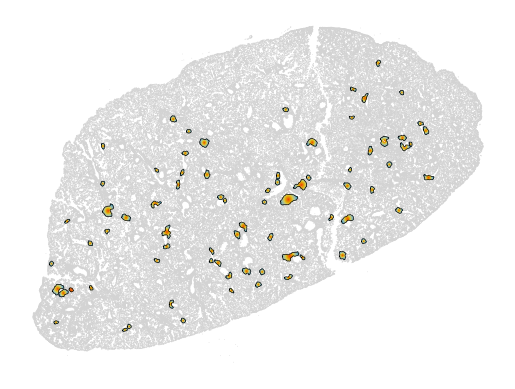

In [25]:
sample_label = 'HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
        
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                # color = 'tls_radial_dist_surr_scaled',
                      # color = 'tls_radial_dist_scaled_combined',
                      title='',
                cmap = colormap_r,
                      colorbar_loc=None,
                frameon=False, 
                size=1, 
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=0.5)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.savefig(os.path.join(plot_out_dir, "tls_radial_tls_dist.png"), dpi=300, bbox_inches='tight', transparent=True)

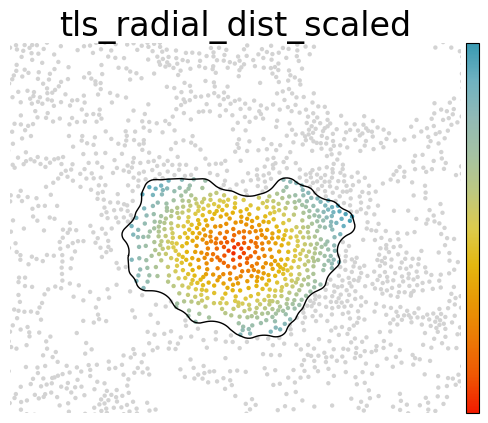

In [26]:
sample_label = 'HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
    
fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                cmap = colormap_r,
                frameon=False, 
                size=40, 
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=1)

for ax in fig.axes:
    if ax.get_label() == '<colorbar>':  
        ax.set_yticks([])
        ax.set_yticklabels([])

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3800, 4200])
plt.ylim([4300, 4700])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_tls_dist_colorbar.png"), dpi=300, bbox_inches='tight', transparent=True)


#### Make a quick colorbar for figure panels!

In [21]:
import matplotlib.cm as cm
# Define the colormap
cmap = colormap_r  # or e.g., cm.viridis_r, cm.Reds, etc.

# Create a dummy scalar mappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(1, 4))  # adjust size as needed

# Add the colorbar to the axis
cb = fig.colorbar(sm, cax=ax)

# Remove ticks and labels
cb.ax.set_yticks([])
cb.ax.set_yticklabels([])

# Remove outline
cb.outline.set_visible(False)

# Save the figure
fig.savefig(os.path.join(plot_out_dir, "colormap_r_clean.png"), dpi=300, bbox_inches='tight', transparent=True)
plt.close(fig)

In [22]:
# categorize cells into tls core, tls outer, or tls surrounding
adata.obs['tls_radial_category'] = pd.cut(adata.obs['tls_radial_dist_scaled'], bins=2, labels=False)
adata.obs.loc[adata.obs['tls_radial_dist_scaled_combined']<=0.5, 'tls_radial_category'] = 'tls core'
adata.obs.loc[adata.obs['tls_radial_dist_scaled_combined']>0.5, 'tls_radial_category'] = 'tls outer'
adata.obs.loc[adata.obs['tls_radial_dist_scaled_combined']>1.0, 'tls_radial_category'] = 'tls surround'
# adata.obs['tls_radial_dist_scaled_bin'] = adata.obs['tls_radial_dist_scaled_bin'] / np.max(adata.obs['tls_radial_dist_scaled_bin']
radial_category_palette = {'tls core': 'darkgreen', 
                           'tls outer':'palegreen', 
                           'tls surround':'darkkhaki'}

(4320.0, 4650.0)

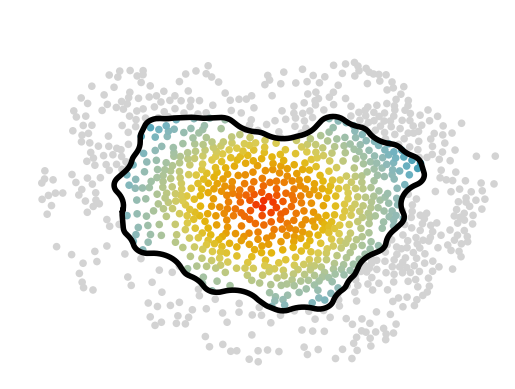

In [23]:
sample_label ='HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_dist_scaled',
                # color = 'tls_radial_dist_surr_scaled',
                cmap = colormap_r,
                      title='',
                frameon=False, 
                size=120, 
                      colorbar_loc=None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
# plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_tls_dist.png"), dpi=300, bbox_inches='tight', transparent=True)


(4320.0, 4650.0)

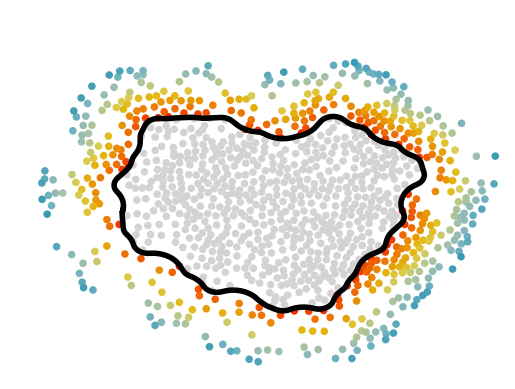

In [24]:
sample_label ='HDM_day3'
    
# get sample subset of adata 
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                # color = 'tls_radial_dist_scaled',
                color = 'tls_radial_dist_surr_scaled',
                cmap = colormap_r,
                      title='',
                frameon=False, 
                size=120, 
                      colorbar_loc=None,
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
# plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_surr_dist.png"), dpi=300, bbox_inches='tight', transparent=True)


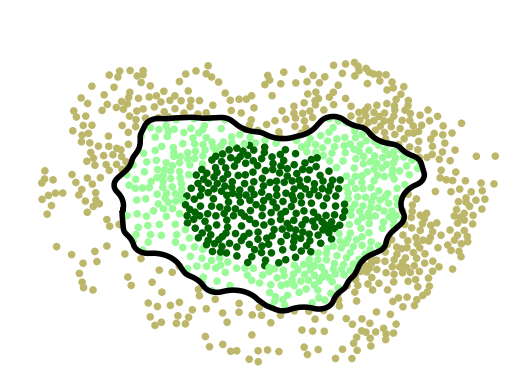

In [33]:
sample_label ='HDM_day3'
adata_sample = adata[adata.obs['sample_label'] == sample_label, :]
adata_sample = adata_sample[~adata_sample.obs['tls_radial_category'].isna(), :]

fig = sc.pl.embedding(adata_sample, basis='spatial', 
                color = 'tls_radial_category', 
                      palette = radial_category_palette,
                      title='',
                frameon=False, 
                size=120, 
                legend_loc = 'none',
                show=False, return_fig=True)

ax = plt.gca()
tls_poly = joblib.load(os.path.join(dist_out_dir, 'tls_poly_' + sample_label + '.pkl'))
for p in tls_poly.geoms:
        ax.plot(*p.exterior.xy, c='black', linewidth=4)

# plt.xlim([2500, 6500])
# plt.ylim([2500, 6500])
plt.xlim([3830, 4160])
plt.ylim([4320, 4650])
plt.savefig(os.path.join(plot_out_dir, "tls_zoom_radial_categories.png"), dpi=300, bbox_inches='tight', transparent=True)

## Plot cytokine/chemokine ligands by zone or tls radial category

In [27]:
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands = df_lr['ligand'].tolist()
ligands_panel = list(set(ligands) & set(adata.var.index))
len(ligands_panel) 

99

In [ ]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1'    
]
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

In [ ]:
# all ligands
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='zone_consol', standard_scale = 'var', swap_axes=False)
sc.pl.dotplot(adata, var_names = ligands_panel, groupby='tls_radial_category', standard_scale = 'var', swap_axes=False)

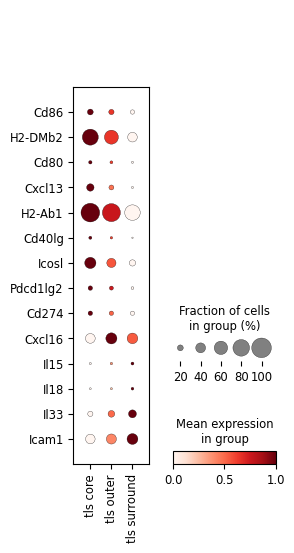

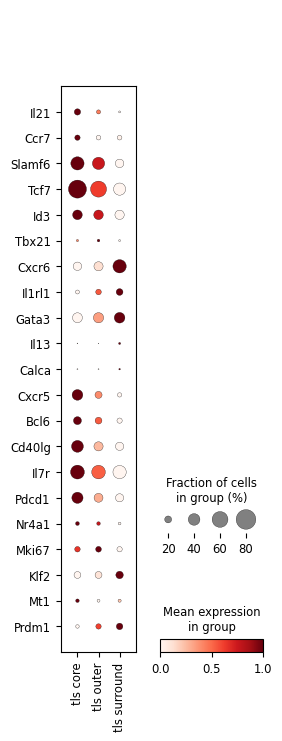

In [34]:
# highlight select 
sc.pl.dotplot(adata, var_names = ligands_highlight, groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)
sc.pl.dotplot(adata[adata.obs['label_medium']=='CD4 act', :], var_names = genes_highlight_tls, groupby='tls_radial_category', standard_scale = 'var', swap_axes=True)

## Cell type composition in radial TLS categories

Text(0.5, 0, '')

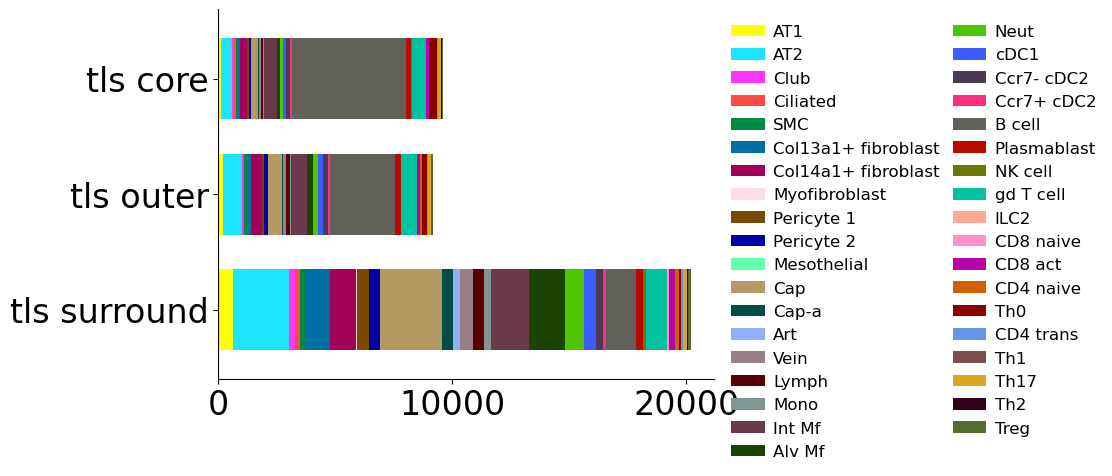

In [26]:
adata_d3 = adata[adata.obs['sample_label']=='HDM_day3', :]
adata_d3_cd4 = adata_d3[adata_d3.obs['label_medium']=='CD4 act', :]
    
zone_col = 'tls_radial_category'
label_col = 'label_fine'
    
ax1 = pu.zone_composition(adata_d3, label_col, zone_col,
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts = True, 
                       zone_ncell_filter = False,
                       horizontal=True
                      )
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('')       
ax1.set_xlabel('')   

## Plotting along radial TLS distance

In [41]:
import scvelo as scv
def scvelo_heatmap(
    adata: sc.AnnData,
    sample_label: list[str],
    sortby: str,
    key_name: str,
    key_value: str = None,
    highlight: list[str] = None,
    n_bins: int = 5,
    col_color = None, 
    palette = None,
    x_clip = None,
    expression_threshold = None, 
    figsize: tuple = None 
):
    """
    Create a heatmap to visualize gene expression trends in single-cell RNA-seq data,
    with options for subsetting, sorting, and highlighting genes.

    Parameters:
    - adata (sc.AnnData): Annotated data object containing single-cell RNA-seq data.
    - sample_label (List[str]): List of batch identifiers to subset the data.
    - key_name (str): String representing the key in `adata.obs` to use for subsetting cells.
    - key_value (str): String representing the value of `key_name` to subset to.
    - sortby (str): Variable to sort the heatmap by (e.g., "crypt_villi_axis").
    - highlight (List[str]): List of labels to highlight on the heatmap.
    - n_bins (int, optional): Integer specifying the number of bins to use for convolution (default: 5).

    Returns:
    - s (seaborn.matrix.ClusterGrid): Matplotlib figure object representing the heatmap.

    This function subsets the input data based on specified sample_labels and key-value pairs,
    filters genes expressed in a minimum percentage of cells, and creates a heatmap
    to visualize gene expression trends along a specified variable. The function also allows
    highlighting specific labels on the y-axis.
    """
    print("Creating Heatmap for sample labels ", " + ".join(sample_label))

    # Subset sample_label
    adata = adata[adata.obs["sample_label"].isin(sample_label)]
    if key_value:
        print(f"Subset to '{key_name}'=='{key_value}'")
        # Subset to key
        adata = adata[adata.obs[key_name] == key_value]
    else:
        print("using all cells")
        
    # Filter to include only genes that are expressed in 5% of the cells
    if expression_threshold:
        print('removing genes by expression threshold: ', expression_threshold, ' fraction')
        adata=filter_adata_expressed_in_n_cells(adata,fraction=expression_threshold)
    else:
        adata = adata.copy()
    print('adata shape: ', adata.shape)

    # Clip x axis
    if x_clip:
        print('clipping x to ', x_clip)
        print('max value before clip ', np.max(adata.obs[sortby]))
        adata = adata[adata.obs[sortby] <= x_clip, :]
        # adata.obs.loc[adata.obs[sortby] > x_clip, sortby] = x_clip
    else: 
        adata = adata.copy()
        
    n_convolve = len(adata) // n_bins
    print(f"Setting `n_convolve` to {n_convolve} ({n_bins} bins, {len(adata)} cells) ")
    # Plot
    s = scv.pl.heatmap(
        adata,
        var_names=adata.var_names,
        sortby=sortby,
        n_convolve=n_convolve,
        show=False,
        yticklabels=True,
        rasterized=True,
        # color_map=colormap,
        color_map='viridis',
        col_color = col_color,
        palette = palette, 
        figsize=figsize
        
    )
    ax = s.ax_heatmap

    # Loop through the x-axis tick labels and show/hide based on the 'highlight' list
    if highlight:
        for i, label in enumerate(ax.get_yticklabels()):
            if label.get_text() not in highlight:
                label.set_visible(False)
                ax.get_yticklines()[2 * i + 1].set_visible(False)
            ax.get_yticklines()[2 * i].set_visible(False)
    else:
        # Make sure all labels and ticks are visible
        for label in ax.get_yticklabels():
            label.set_visible(True)
    
        for tickline in ax.get_yticklines():
            tickline.set_visible(False)  # optional: hide all tick lines
        

    ax.set_xlabel("")
    ax.set_title("")
    return s

In [42]:
genes_highlight_tls = ['Il21', 'Ccr7', 'Slamf6', 'Tcf7', 'Id3', 'Tbx21', 'Cxcr6', 'Il1rl1', 'Gata3', 'Il13', 'Calca',
                       'Irf4',
                       'Cxcr5', 'Bcl6', 'Cd40lg', 'Il7r',
                      'Pdcd1', 'Tigit', 'Nr4a1', 'Mki67',
                      'Klf2', 'Mt1', 'Prdm1']

In [43]:
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv('/home/workspace/spatial_mouse_lung_outputs/distance_analysis/ouputs_mouselung_xenseg_HDM/R/cite_expressed_genes_by_annotation.csv')
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
adata_cd4 = adata.copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
removing genes by expression threshold:  0.05  fraction
adata shape:  (1610, 164)
Setting `n_convolve` to 322 (5 bins, 1610 cells) 


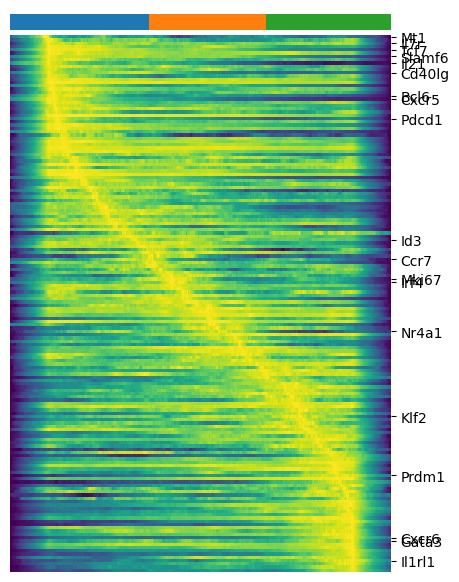

In [54]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    highlight = genes_highlight_tls,
    expression_threshold= 0.05, # filter in addition to genes cite filter (since now analyze just the tls associated subset)
    figsize=(5,6)
    # figsize=(5,16)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
# plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


HDM_day3
Creating Heatmap for sample labels  HDM_day3
Subset to 'label_medium'=='CD4 act'
removing genes by expression threshold:  0.05  fraction
adata shape:  (1610, 164)
Setting `n_convolve` to 322 (5 bins, 1610 cells) 


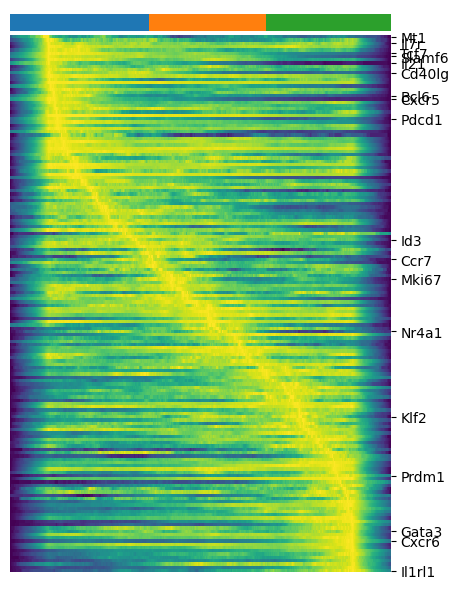

In [107]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,genes_cite_xen_filt],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    key_value = 'CD4 act',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    highlight = genes_highlight_tls,
    expression_threshold= 0.05, # filter in addition to genes cite filter (since now analyze just the tls associated subset)
    figsize=(5,6)
    # figsize=(5,16)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4.pdf"), dpi=300, bbox_inches='tight', transparent=True)
# plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_CD4_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


## ligands

In [56]:
df_lr = pd.read_csv(inputs_dir, 'interaction_input_CellChatDB.csv')

ligands = df_lr['ligand'].tolist()

ligands_panel = list(set(ligands) & set(adata.var.index))
len(ligands_panel)

99

In [57]:
ligands_highlight = ['Cd86', 'H2-DMb2', 'Cd80', 'Cxcl13', 'H2-Ab1', 
                     'Cd40lg', 'Icosl', 'Pdcd1lg2', 'Cd274', 
                     'Cxcl16', 'Il15', 'Il18', 'Il33', 'Icam1'    
]

HDM_day3
Creating Heatmap for sample labels  HDM_day3
using all cells
removing genes by expression threshold:  0.05  fraction
adata shape:  (38988, 54)
Setting `n_convolve` to 7797 (5 bins, 38988 cells) 


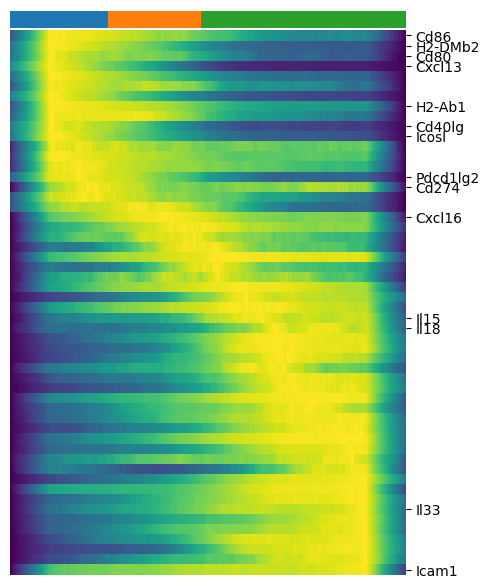

In [61]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,ligands_panel],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    key_value = None,
    highlight = ligands_highlight,
    expression_threshold= 0.05,
    figsize=(5,6)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_allcells_ligands.pdf"), dpi=300, bbox_inches='tight', transparent=True)


HDM_day3
Creating Heatmap for sample labels  HDM_day3
using all cells
removing genes by expression threshold:  0.05  fraction
adata shape:  (38988, 54)
Setting `n_convolve` to 7797 (5 bins, 38988 cells) 


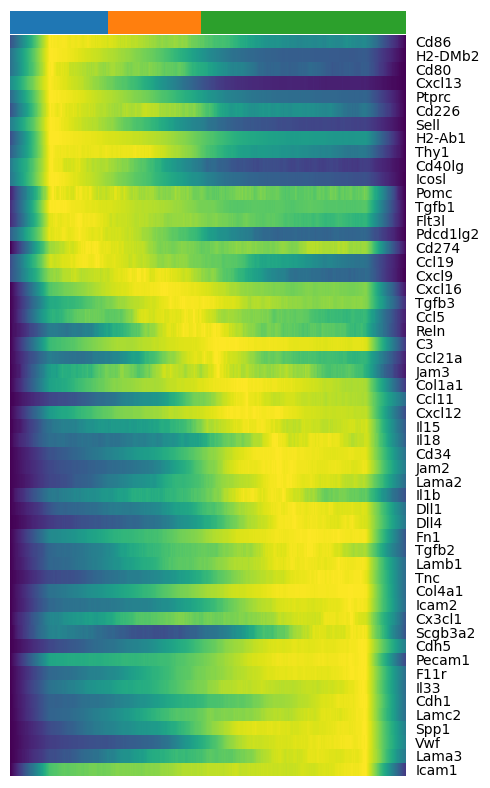

In [63]:
sample_label = 'HDM_day3'
print(sample_label)
adata_plot = adata[adata.obs['sample_label']==sample_label, :]
adata_plot = adata_plot[~adata_plot.obs['tls_radial_dist_scaled_combined'].isna(), :]
s = scvelo_heatmap(
    adata_plot[:,ligands_panel],
    sample_label=[sample_label],
    sortby = 'tls_radial_dist_scaled_combined',
    key_name = 'label_medium',
    col_color = 'tls_radial_category',
    palette = radial_category_palette,
    key_value = None,
    highlight = None,
    expression_threshold= 0.05,
    figsize=(5,8)
)
s
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_scVelo_tls_radial_dist_scaled_combined_allcells_ligands_showallgenes.pdf"), dpi=300, bbox_inches='tight', transparent=True)


In [51]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active conda environment:  space2
